# Week 1 — Data Cleaning & Preparation


## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Inspecting The Dataset

In [ ]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 9994
Number of columns: 21


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

## Checking For Missing Values

In [28]:
missing_values = df.isnull().sum()

missing_values

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Checking For Any Duplicates

In [29]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


## Checking For Unique Values

## Ship Mode

In [ ]:
df["Ship Mode"].unique()

<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

## Segment

In [31]:
df["Segment"].unique() 

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

## Region

In [34]:
df["Region"].unique()

<StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

## Category

In [35]:
df["Category"].unique()

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

## Checking Number of Distinct Values

In [36]:
df.nunique()

Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64

## Checking Data Types

In [40]:
# Checkiing Data Types
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

## Convert Date Columns

In [41]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [42]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

## Checking Numerical Values

In [43]:
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

df[numeric_columns].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


## Check Negative Sales Values

In [44]:
negative_sales = df[df["Sales"] < 0]

print(f"Negative sales records: {len(negative_sales)}")

Negative sales records: 0


In [45]:
zero_sales = df[df["Sales"] == 0]

print(f"Zero sales records: {len(zero_sales)}")

Zero sales records: 0


## Checking Quantity

In [46]:
invalid_quantity = df[df["Quantity"] <= 0]

print(f"Invalid quantity records: {len(invalid_quantity)}")

Invalid quantity records: 0


## Checking Discount

In [47]:
invalid_discount = df[
    (df["Discount"] < 0) |
    (df["Discount"] > 1)
]

print(f"Invalid discount records: {len(invalid_discount)}")

Invalid discount records: 0


In [ ]:
#Checking available discounts

sorted(df["Discount"].unique())

[np.float64(0.0),
 np.float64(0.1),
 np.float64(0.15),
 np.float64(0.2),
 np.float64(0.3),
 np.float64(0.32),
 np.float64(0.4),
 np.float64(0.45),
 np.float64(0.5),
 np.float64(0.6),
 np.float64(0.7),
 np.float64(0.8)]

## Investigating Negative Profit

In [49]:
negative_profit = df[df["Profit"] < 0]

print(f"Records with negative profit: {len(negative_profit)}")

Records with negative profit: 1871


## Checking Invalid Shipping Dates

In [51]:
invalid_shipping_dates = df[
    df["Ship Date"] < df["Order Date"]
]

print(f"Invalid shipping date records: {len(invalid_shipping_dates)}")

Invalid shipping date records: 0


In [ ]:
# Creating Shipping Dates

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [53]:
df[[
    "Order Date",
    "Ship Date",
    "Shipping Days"
]].head()

,Order Date,Ship Date,Shipping Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [57]:
df["Shipping Days"].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

## Checking Shipping Dates

In [58]:
df["Shipping Days"].value_counts().sort_index()

Shipping Days
0     519
1     369
2    1334
3    1005
4    2774
5    2169
6    1203
7     621
Name: count, dtype: int64

## Checking Outliers With Boxplots

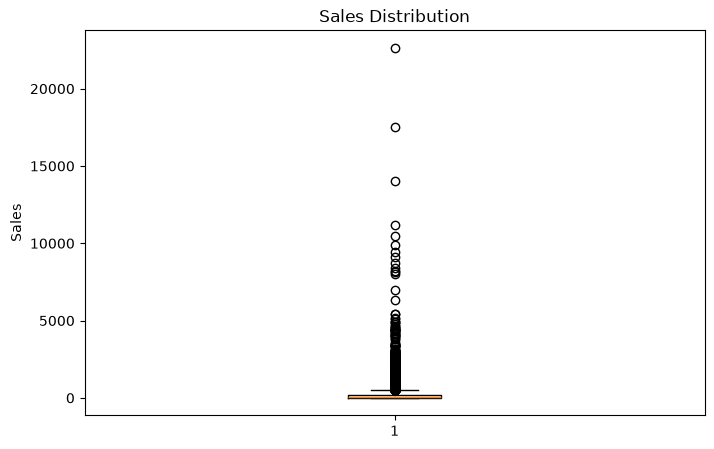

In [ ]:
#Sales Distribution

plt.figure(figsize=(8, 5))

plt.boxplot(df["Sales"])

plt.title("Sales Distribution")
plt.ylabel("Sales")

plt.show()

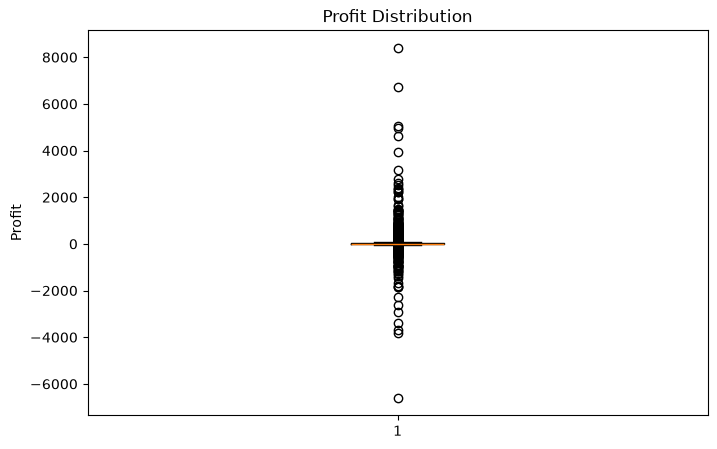

In [ ]:
Profit Distribution

plt.figure(figsize=(8, 5))

plt.boxplot(df["Profit"])

plt.title("Profit Distribution")
plt.ylabel("Profit")

plt.show()

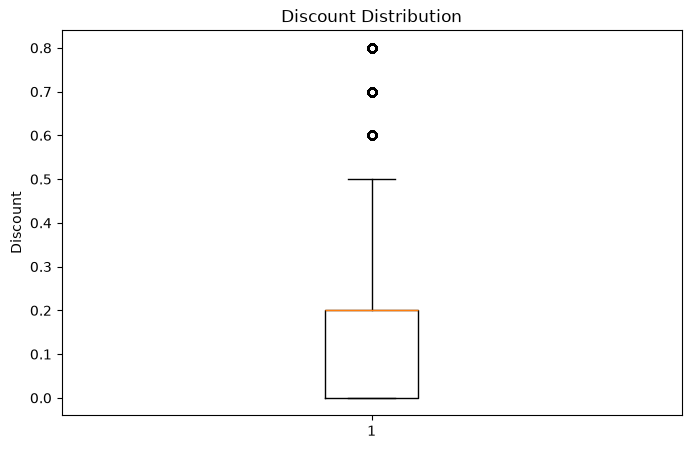

In [63]:
# Discount Distribution

plt.figure(figsize=(8, 5))

plt.boxplot(df["Discount"])

plt.title("Discount Distribution")
plt.ylabel("Discount")

plt.show()

In [ ]:
# Detecting Outliers in Sales

Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sales_outliers = df[
    (df["Sales"] < lower_bound) |
    (df["Sales"] > upper_bound)
]

print(f"Potential Sales outliers: {len(sales_outliers)}")

Potential Sales outliers: 1167


## Investigating The Largest Sales


In [66]:
df.nlargest(10, "Sales")[
    [
        "Order ID",
        "Customer Name",
        "Product Name",
        "Category",
        "Sales",
        "Profit"
    ]
]

,Order ID,Customer Name,Product Name,Category,Sales,Profit
2697,CA-2014-145317,Sean Miller,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,-1811.0784
6826,CA-2016-118689,Tamara Chand,Canon imageCLASS 2200 Advanced Copier,Technology,17499.950,8399.9760
8153,CA-2017-140151,Raymond Buch,Canon imageCLASS 2200 Advanced Copier,Technology,13999.960,6719.9808
2623,CA-2017-127180,Tom Ashbrook,Canon imageCLASS 2200 Advanced Copier,Technology,11199.968,3919.9888
4190,CA-2017-166709,Hunter Lopez,Canon imageCLASS 2200 Advanced Copier,Technology,10499.970,5039.9856
9039,CA-2016-117121,Adrian Barton,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,9892.740,4946.3700
4098,CA-2014-116904,Sanjit Chand,Ibico EPK-21 Electric Binding System,Office Supplies,9449.950,4630.4755
4277,US-2016-107440,Bill Shonely,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,9099.930,2365.9818
8488,CA-2016-158841,Sanjit Engle,HP Designjet T520 Inkjet Large Format Printer ...,Technology,8749.950,2799.9840
6425,CA-2016-143714,Christopher Conant,Canon imageCLASS 2200 Advanced Copier,Technology,8399.976,1119.9968


## Standardizing Column Names

In [67]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)

In [68]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit',
       'shipping_days'],
      dtype='str')

## Final Data Quality Check

In [69]:
print("Dataset shape:", df.shape)

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nTotal duplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (9994, 22)

Total missing values:
0

Total duplicate rows:
0

Data types:
row_id                    int64
order_id                    str
order_date       datetime64[us]
ship_date        datetime64[us]
ship_mode                   str
customer_id                 str
customer_name               str
segment                     str
country                     str
city                        str
state                       str
postal_code               int64
region                      str
product_id                  str
category                    str
sub-category                str
product_name                str
sales                   float64
quantity                  int64
discount                float64
profit                  float64
shipping_days             int64
dtype: object


## Final Preview

In [ ]:
# Showing First Five Rows of the Dataset

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


In [ ]:
# Showing Last Five Rows of the Dataset

df.tail()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_days
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028,2
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332,5
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932,5
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200,5
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480,5


## Saving The Cleaned Dataset

In [73]:
df.to_csv("Superstore_Cleaned.csv", index=False)

print("Cleaned dataset successfully saved.")

Cleaned dataset successfully saved.


# Week 2 — Exploratory Data Analysis & Business Insights

## Superstore Sales & KPI Analysis

## Data Analytics Internship – Week 2

### Objective

The objective of this week is to perform Exploratory Data Analysis (EDA)
and analyze the sales performance of the Superstore dataset.

The analysis will focus on:

- Key business performance indicators (KPIs)
- Sales performance
- Profitability
- Order and customer activity
- Sales trends over time
- Regional performance
- Category performance
- Business insights and findings

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Checking Loaded Cleaned Dataset From Week 1

In [17]:
df = pd.read_csv("Superstore_Cleaned.csv")

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


## Checking The Dataset

In [6]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 9994
Columns: 22


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   str    
 2   order_date     9994 non-null   str    
 3   ship_date      9994 non-null   str    
 4   ship_mode      9994 non-null   str    
 5   customer_id    9994 non-null   str    
 6   customer_name  9994 non-null   str    
 7   segment        9994 non-null   str    
 8   country        9994 non-null   str    
 9   city           9994 non-null   str    
 10  state          9994 non-null   str    
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   str    
 13  product_id     9994 non-null   str    
 14  category       9994 non-null   str    
 15  sub-category   9994 non-null   str    
 16  product_name   9994 non-null   str    
 17  sales          9994 non-null   float64
 18  quantity       9994

## Converting Dates

In [11]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

df[["order_date", "ship_date"]].dtypes

order_date    datetime64[us]
ship_date     datetime64[us]
dtype: object

## Defining The Analysis Period

In [21]:
## Checking the period the datasets cover

print("Start date:", df["order_date"].min())
print("End date:", df["order_date"].max())

Start date: 2014-01-03
End date: 2017-12-30


## Checking Core KPI Calculations

In [22]:
total_sales = df["sales"].sum()

total_profit = df["profit"].sum()

total_orders = df["order_id"].nunique()

total_customers = df["customer_id"].nunique()

total_quantity = df["quantity"].sum()

profit_margin = (total_profit / total_sales) * 100

average_order_value = total_sales / total_orders

In [23]:
## Displaying KPIs

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Average Order Value: ${average_order_value:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793
Total Quantity Sold: 37,873
Profit Margin: 12.47%
Average Order Value: $458.61


## Creating KPI Summary Table

In [24]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Total Quantity Sold",
        "Profit Margin",
        "Average Order Value"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        total_quantity,
        profit_margin,
        average_order_value
    ]
})

kpi_summary

,KPI,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Orders,5.009000e+03
3,Total Customers,7.930000e+02
4,Total Quantity Sold,3.787300e+04
5,Profit Margin,1.246722e+01
6,Average Order Value,4.586147e+02


## Sales Trend Analysis

In [29]:
df["year"] = df["order_date"].dt.year

df["month"] = df["order_date"].dt.month

df["month_name"] = df["order_date"].dt.month_name()

In [30]:
df[["order_date", "year", "month", "month_name"]].head()

,order_date,year,month,month_name
0,2016-11-08,2016,11,November
1,2016-11-08,2016,11,November
2,2016-06-12,2016,6,June
3,2015-10-11,2015,10,October
4,2015-10-11,2015,10,October


## Creating Year-Month

In [31]:
df["year_month"] = df["order_date"].dt.to_period("M")

In [32]:
df[["order_date", "year_month"]].head()

,order_date,year_month
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


## Sales By Year

In [33]:
sales_by_year = (
    df.groupby("year")["sales"]
    .sum()
    .reset_index()
)

sales_by_year

,year,sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


## Visualizing Sales By Year

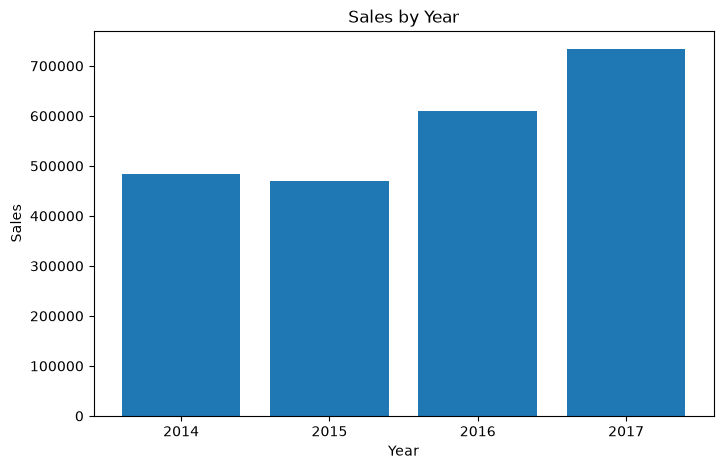

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(
    sales_by_year["year"].astype(str),
    sales_by_year["sales"]
)

plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()

## Monthly Sales

In [35]:
monthly_sales = (
    df.groupby("year_month")["sales"]
    .sum()
    .reset_index()
)

monthly_sales

,year_month,sales
0,2014-01,14236.8950
1,2014-02,4519.8920
2,2014-03,55691.0090
3,2014-04,28295.3450
4,2014-05,23648.2870
5,2014-06,34595.1276
6,2014-07,33946.3930
7,2014-08,27909.4685
8,2014-09,81777.3508
9,2014-10,31453.3930


## Monthly Sales Trend

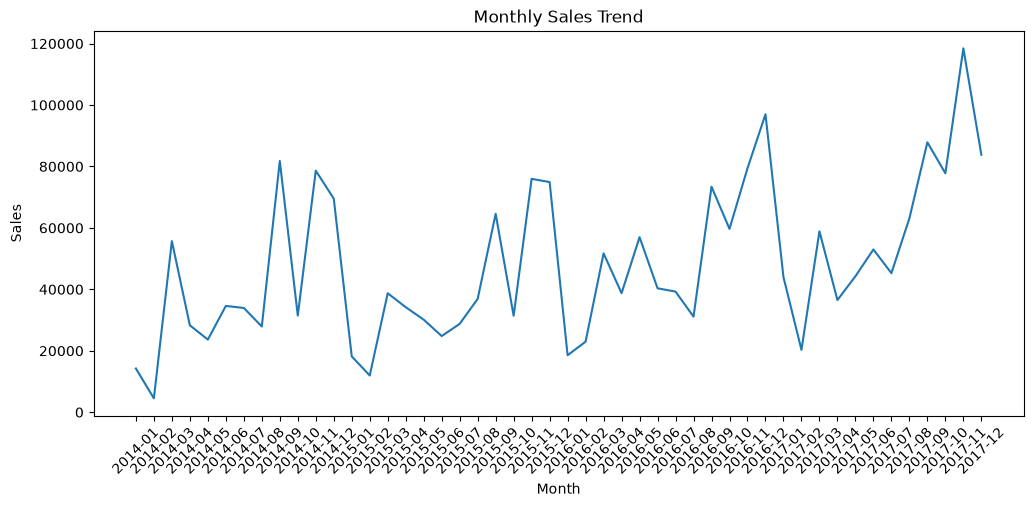

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["year_month"].astype(str),
    monthly_sales["sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

## Monthly Profit

In [23]:
monthly_profit = (
    df.groupby("year_month")["profit"]
    .sum()
    .reset_index()
)

monthly_profit.head()

,year_month,profit
0,2014-01,2450.1907
1,2014-02,862.3084
2,2014-03,498.7299
3,2014-04,3488.8352
4,2014-05,2738.7096


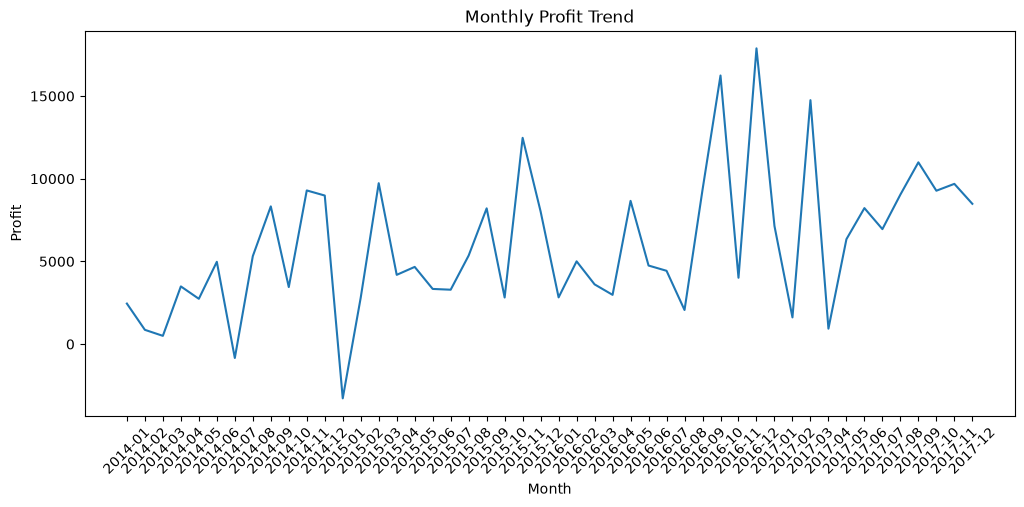

In [ ]:
## Checking Monthly Profit Trend


plt.figure(figsize=(12, 5))

plt.plot(
    monthly_profit["year_month"].astype(str),
    monthly_profit["profit"]
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

## Regional Analysis

In [36]:
## Sales By Region

sales_by_region = (
    df.groupby("region")["sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_region

region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64

## Visualize Sales By Region

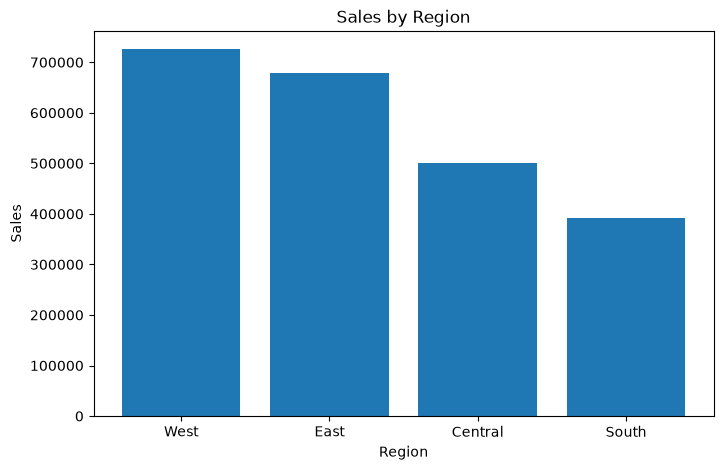

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(
    sales_by_region.index,
    sales_by_region.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

## Profit By Region

In [38]:
profit_by_region = (
    df.groupby("region")["profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_region

region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: profit, dtype: float64

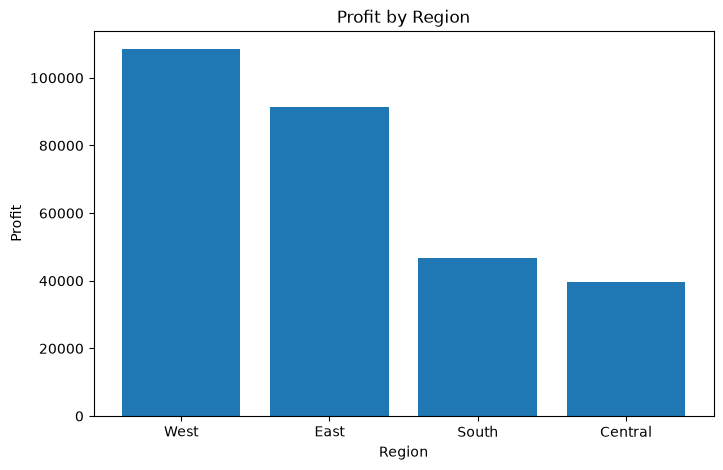

In [35]:
## Visualizing Profit by Region

plt.figure(figsize=(8, 5))

plt.bar(
    profit_by_region.index,
    profit_by_region.values
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

## Regional KPIs

In [39]:
regional_analysis = df.groupby("region").agg(
    sales=("sales", "sum"),
    profit=("profit", "sum"),
    orders=("order_id", "nunique"),
    quantity=("quantity", "sum")
).reset_index()

In [40]:
## Calculating Profit Margin for Each Region

regional_analysis["profit_margin"] = (
    regional_analysis["profit"] /
    regional_analysis["sales"]
) * 100

In [41]:
regional_analysis.sort_values(
    "sales",
    ascending=False
)

,region,sales,profit,orders,quantity,profit_margin
3,West,725457.8245,108418.4489,1611,12266,14.944831
1,East,678781.2400,91522.7800,1401,10618,13.483399
0,Central,501239.8908,39706.3625,1175,8780,7.921629
2,South,391721.9050,46749.4303,822,6209,11.934342


## Category Analysis

In [42]:
category_analysis = df.groupby("category").agg(
    sales=("sales", "sum"),
    profit=("profit", "sum"),
    quantity=("quantity", "sum")
).reset_index()

category_analysis

,category,sales,profit,quantity
0,Furniture,741999.7953,18451.2728,8028
1,Office Supplies,719047.0320,122490.8008,22906
2,Technology,836154.0330,145454.9481,6939


## Sales by Category

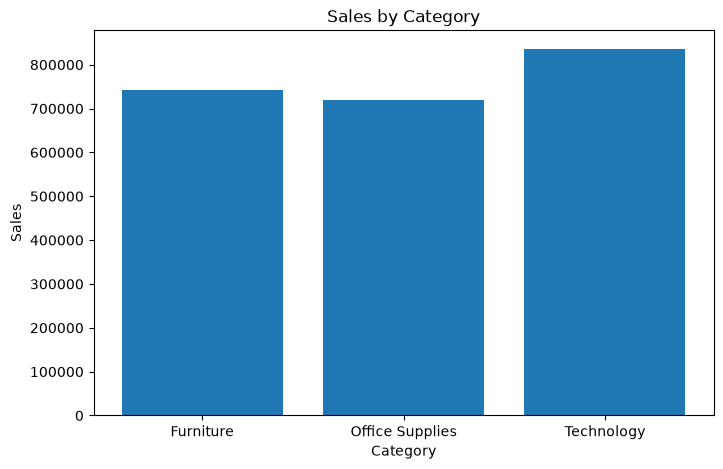

In [43]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis["category"],
    category_analysis["sales"]
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

## Profit by Category

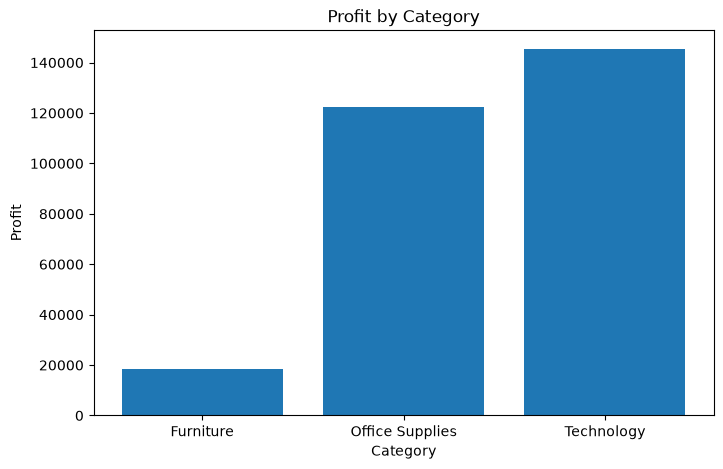

In [44]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis["category"],
    category_analysis["profit"]
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

## Quantity by Category

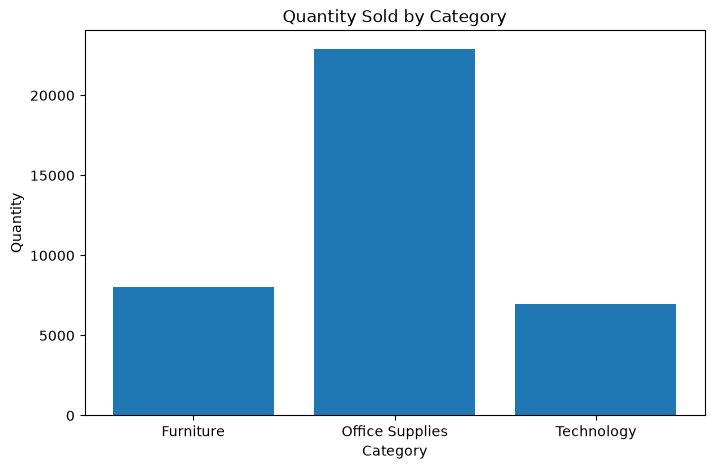

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis["category"],
    category_analysis["quantity"]
)

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity")

plt.show()

## Category Profit Margin

In [46]:
category_analysis["profit_margin"] = (
    category_analysis["profit"] /
    category_analysis["sales"]
) * 100

In [47]:
category_analysis.sort_values(
    "profit_margin",
    ascending=False
)

,category,sales,profit,quantity,profit_margin
2,Technology,836154.0330,145454.9481,6939,17.395712
1,Office Supplies,719047.0320,122490.8008,22906,17.035158
0,Furniture,741999.7953,18451.2728,8028,2.486695


## Identifying Top Performing Region

In [48]:
top_sales_region = sales_by_region.idxmax()

top_sales_value = sales_by_region.max()

print(
    f"The region with the highest sales is "
    f"{top_sales_region} with ${top_sales_value:,.2f} in sales."
)

The region with the highest sales is West with $725,457.82 in sales.


## Identifying Top Performing Category

In [49]:
top_sales_category = (
    category_analysis.loc[
        category_analysis["sales"].idxmax(),
        "category"
    ]
)

top_sales_category

'Technology'

## Finding Most Profitable Category

In [50]:
top_profit_category = (
    category_analysis.loc[
        category_analysis["profit"].idxmax(),
        "category"
    ]
)

print(
    f"The most profitable category is "
    f"{top_profit_category}."
)

The most profitable category is Technology.


# Key Business Insights

Based on the exploratory analysis performed in this notebook, the following business insights were identified:

### Insight 1 — Overall Performance
The business generated $2,297,200.86 in total sales** and $286,397.02 in total profit from 5,009 orders. The overall profit margin was 12.47%, indicating that the business generated a positive return from its recorded sales activity.

### Insight 2 — Sales Trend
Monthly sales fluctuated significantly throughout the analysis period, with several noticeable peaks and declines. Overall, sales activity increased toward the later years, with the highest monthly sales occurring in October 2017 at approximately $118,000.

### Insight 3 — Regional Performance
The West region generated the highest sales, with approximately $725,000 in total sales, followed by the East region with approximately $680,000. The South region recorded the lowest sales, at approximately $390,000, indicating a substantial difference in sales contribution across regions.

### Insight 4 — Category Performance
Technology was the strongest-performing category, generating approximately $836,000 in sales, followed by Furniture at approximately $743,000 and Office Supplies at approximately $719,000. However, sales volume did not translate evenly into profit — Office Supplies recorded the highest quantity sold at roughly 23,000 units, compared to only about 8,000 units for Furniture and 7,000 for Technology, indicating that Office Supplies operates on a high-volume, lower-price-point model relative to the other two categories.

### Insight 5 — Profitability
Profitability varied sharply across categories despite relatively similar sales figures. Technology delivered the highest profit at approximately $145,500 (a margin of roughly 17.4%), and Office Supplies followed closely with approximately $122,000 in profit (a margin of roughly 17%). Furniture, by contrast, generated only about $18,500 in profit despite sales nearly on par with Technology, resulting in a margin of just 2.5% — the weakest of the three categories. This gap suggests that Furniture's profitability is disproportionately affected by higher costs, discounting, or fulfillment expenses relative to its revenue, making it a priority area for margin investigation